In [1]:
import pickle
import os
import sys
import numpy as np
import pandas as pd
from deepmreye import analyse, architecture, preprocess, train
from deepmreye.util import data_generator, model_opts, util
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 

subject_pool = {
                'sub-003':{'ses-07R':([1,2,3,4,5], False),
                           'ses-13R':([1,2,4,5,6], False)},
                'sub-004':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-005':{'ses-07':([1,2,3,4,5,6], True)},
                'sub-006':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-008':{'ses-07R':([2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-009':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,5,6], False)},
                'sub-010':{'ses-07':([1,2,3,4,5], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-011':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-012':{'ses-07':([1,2,4,5,6], False)},
                'sub-013':{'ses-07':([1,2,3,4], False)},
                'sub-014':{'ses-07':([2,3,4,5,6], False)},
                'sub-015':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-016':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-017':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5], False)},
                'sub-018':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-020':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-021':{'ses-07':([1,2,4,5,6], False),
                           'ses-13':([1,2,4,5,6], False)},
                'sub-JJY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-KMY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-PJW':{'ses-07':([1,2,3,4,6], True)},
                'sub-PBJ':{'ses-07':([1,2,3,4,5], False)}
                }

with open('minecraft_testable_data_extend3.pkl', 'rb') as f:
    testable_data = pickle.load(f)

task = 'task-mcHERDING'
space = 'space-MNI152NLin2009cAsym'
prefix = 'desc-preproc_bold.nii.gz'

2024-12-13 17:25:39.231112: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-13 17:25:39.310388: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-13 17:25:40.489687: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
import os
from tensorflow.keras.callbacks import Callback
class LossHistoryCallback(Callback):
  def __init__(self, filename):
    super().__init__()
    self.filename = filename
    with open(self.filename, "w") as f:
      f.write("Epoch,Training Loss\n")
          
  def on_epoch_end(self, epoch, logs=None):
    training_loss = logs.get('loss', 'NA')
    with open(self.filename, "a") as f:
      f.write(f"{epoch+1},{training_loss}\n")

for key in testable_data.keys():
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])
    print(subject, session, task, run)
    
    data = np.load(f'processed_data/{subject}_{session}_{run}_train.npz', mmap_mode='r')
    X = [data['data_' + str(b)] for b in range(24)]
    y = [data['label_' + str(b)] for b in range(24)]
    X = np.array(X)[..., np.newaxis]
    y = np.array(y)
    opts = model_opts.get_opts()
        
    opts["epochs"] = 120
    opts["gaussian_noise"] = 1.0
    lr_sched = util.step_decay_schedule(initial_lr=opts['lr'], decay_factor=0.95, num_epochs=opts["epochs"])
    
    loss_history_callback = LossHistoryCallback(filename=f'loss_history/{subject}_{session}_{run}_loss_finetuned.txt')
    model, model_inference = architecture.create_standard_model(X.shape[1::], opts)
    model.load_weights(f'model_weights/pretrained_weight_datasets_1to6.h5')
    model.fit([X, y], 
              epochs=opts["epochs"], 
              callbacks=[lr_sched, loss_history_callback], 
              use_multiprocessing=True, 
              workers=8,
              )
    model_inference.save_weights(f'model_weights/{subject}_{session}_{run}_model_finetuned.h5')
  

sub-003 ses-07R task-mcHERDING run-1
Epoch 1/120
1/1 [==============================] - 27s 27s/step - loss: 10.0439 - lr: 2.0000e-05
Epoch 2/120
1/1 [==============================] - 1s 1s/step - loss: 8.4774 - lr: 1.9842e-05
Epoch 3/120
1/1 [==============================] - 1s 1s/step - loss: 7.9441 - lr: 1.9683e-05
Epoch 4/120
1/1 [==============================] - 2s 2s/step - loss: 7.5546 - lr: 1.9525e-05
Epoch 5/120
1/1 [==============================] - 2s 2s/step - loss: 7.3222 - lr: 1.9366e-05
Epoch 6/120
1/1 [==============================] - 1s 1s/step - loss: 7.1379 - lr: 1.9207e-05
Epoch 7/120
1/1 [==============================] - 1s 1s/step - loss: 6.9287 - lr: 1.9049e-05
Epoch 8/120
1/1 [==============================] - 1s 1s/step - loss: 6.7971 - lr: 1.8890e-05
Epoch 9/120
1/1 [==============================] - 2s 2s/step - loss: 6.5933 - lr: 1.8731e-05
Epoch 10/120
1/1 [==============================] - 1s 1s/step - loss: 6.4370 - lr: 1.8572e-05
Epoch 11/120
1/1 [=

KeyboardInterrupt: 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


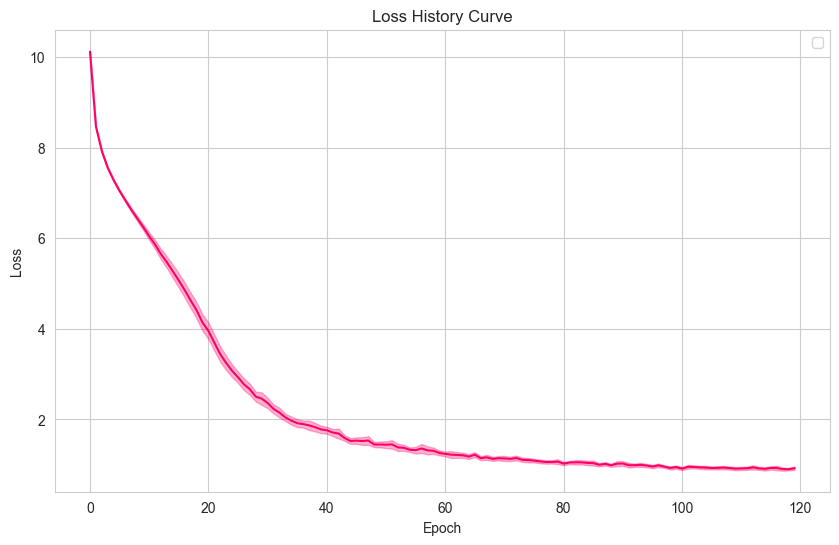

In [7]:
import matplotlib.pyplot as plt 
from scipy.stats import sem

subject_loss = {}
for key in testable_data.keys():
    subject, session, task, run = key
    if subject not in subject_loss:
        subject_loss[subject] = []
    loss_history = pd.read_csv(f'loss_history/{subject}_{session}_{run}_loss_finetuned.txt')
    subject_loss[subject].append(np.array(loss_history['Training Loss']))

for subject in subject_loss.keys():
    subject_loss[subject] = np.mean(subject_loss[subject], axis=0)
    
subject_loss_mean = np.mean([subject_loss[subject] for subject in subject_loss], axis=0)
subject_loss_se = sem([subject_loss[subject] for subject in subject_loss], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(120), subject_loss_mean, c='#ff0064')
plt.fill_between(np.arange(120),
                     subject_loss_mean - subject_loss_se,
                     subject_loss_mean + subject_loss_se,
                     color='#ff0064', alpha=0.3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss History Curve")
plt.legend()
plt.grid(True)

In [13]:
calibration_points = np.array([[200-800, 166-500], [200-800, 500-500], [200-800, 833-500],
                               [600-800, 166-500], [600-800, 500-500], [600-800, 833-500],
                               [1000-800, 166-500], [1000-800, 500-500], [1000-800, 833-500],
                               [1400-800, 166-500], [1400-800, 500-500], [1400-800, 833-500]]) * (1/78.43)
calibration_points = np.tile(calibration_points, [2,1])
calibration_order = np.array([4,11,6,2,7,0,10,5,9,8,1,3]*2)

calibration_gt = calibration_points[calibration_order, :]

calibration_time = np.arange(0,24,0.1)
calibration_x = np.zeros(240)
calibration_y = np.zeros(240)
for t, time in enumerate(calibration_time):
    x = calibration_gt[int(np.floor(time)), 0]
    y = calibration_gt[int(np.floor(time)), 1]
    calibration_x[t] = x
    calibration_y[t] = y

offsets = [1, 144, 284, 494]
n_points = [24, 12, 12, 12]

subject_RMSEs = {}
for key in testable_data.keys():
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])
    print(subject, session, task, run)
    if subject not in list(subject_RMSEs.keys()):
        subject_RMSEs[subject] = []
    
    #
    test_data = np.load(f'processed_data/{subject}_{session}_{run}_test.npz', mmap_mode='r')
    
    test_X = [test_data['data_' + str(b)] for b in range(510)]
    test_y = [test_data['label_' + str(b)] for b in range(510)]
    test_X = np.array(test_X)[..., np.newaxis]
    test_y = np.array(test_y)
    
    opts = model_opts.get_opts()
    _, model_inference = architecture.create_standard_model(test_X.shape[1::], opts)
    model_inference.load_weights(f'model_weights/{subject}_{session}_{run}_model_finetuned.h5')
    (pred_y, euc_pred) = model_inference.predict(test_X)
    
    pred_y = np.median(pred_y, axis=1) #Original Figure_5_DeepMReye evaluation funcation used np.median
    np.save(f'results/{subject}_{session}_{run}_pred_finetuned.npy', pred_y)

    train_RMSE = []
    for t, time in enumerate(range(1, 25)):
        x_pred = pred_y[time,0]
        y_pred = pred_y[time,1]
        x_data = calibration_gt[t,0] #np.mean(calibration_x[t*10:(t+1)*10])
        y_data = calibration_gt[t,1] #np.mean(calibration_y[t*10:(t+1)*10])
        train_RMSE.append(np.sqrt((x_pred-x_data)**2 + (y_pred-y_data)**2))
        
    t_eval = 3
    test_RMSE = []
    for t, time in enumerate(range(offsets[t_eval], offsets[t_eval]+n_points[t_eval])):
        x_pred = pred_y[time,0]
        y_pred = pred_y[time,1]
        x_data = calibration_gt[t,0] #np.mean(calibration_x[t*10:(t+1)*10])
        y_data = calibration_gt[t,1] #np.mean(calibration_y[t*10:(t+1)*10])
        test_RMSE.append(np.sqrt((x_pred-x_data)**2 + (y_pred-y_data)**2))
    subject_RMSEs[subject].append(np.mean(test_RMSE))
    print(np.mean(train_RMSE), np.mean(test_RMSE))

print(subject_RMSEs)

sub-003 ses-07R task-mcHERDING run-1
16/16 [==============================] - 13s 674ms/step
4.150576557927132 5.1511791527460415
sub-003 ses-07R task-mcHERDING run-2
16/16 [==============================] - 13s 657ms/step
2.9549154304025556 5.101435200771834
sub-003 ses-07R task-mcHERDING run-3
16/16 [==============================] - 13s 658ms/step
3.194960454487689 6.0914939849139875
sub-003 ses-13R task-mcHERDING run-1
16/16 [==============================] - 12s 622ms/step
3.6725489030831633 6.80494031936513
sub-003 ses-13R task-mcHERDING run-2
16/16 [==============================] - 12s 656ms/step
2.5096507226068776 5.567104913471805
sub-003 ses-13R task-mcHERDING run-4
16/16 [==============================] - 13s 682ms/step
3.2418255990207903 5.800962601847854
sub-003 ses-13R task-mcHERDING run-5
16/16 [==============================] - 13s 690ms/step
4.539763545353825 5.303338305307858
sub-004 ses-07R task-mcHERDING run-1
16/16 [==============================] - 12s 634ms/step

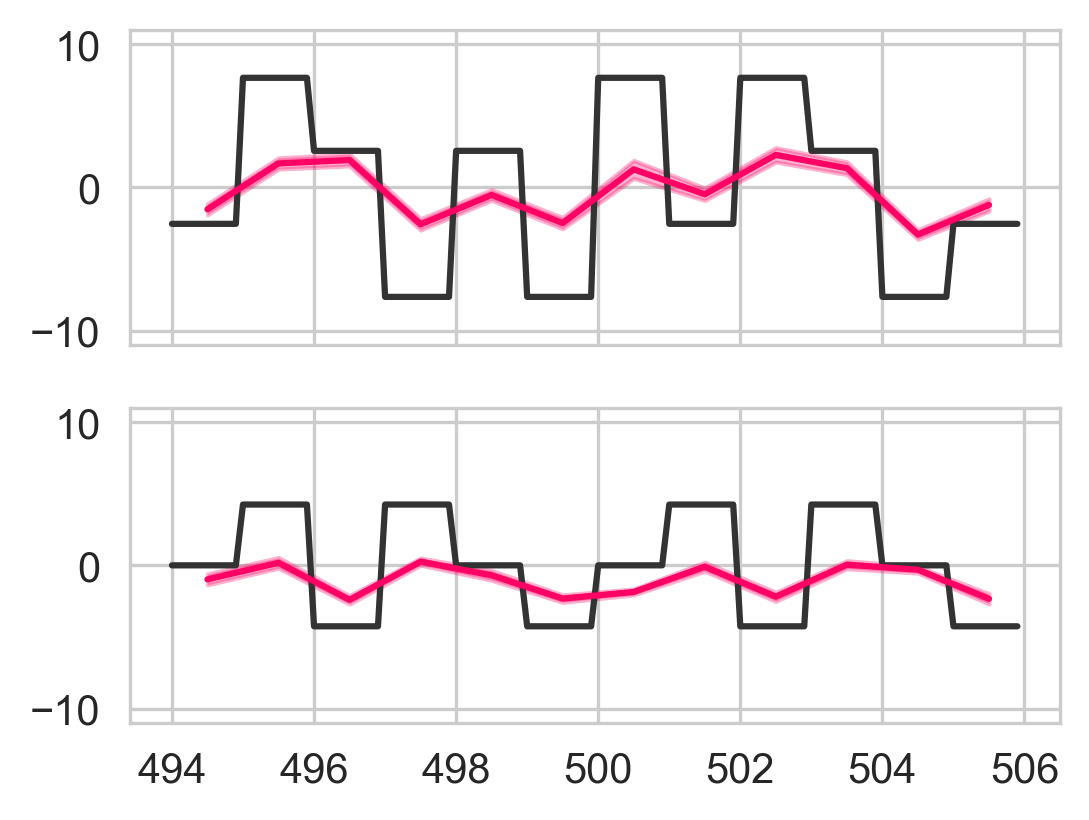

In [14]:
from scipy.stats import sem
import matplotlib.pyplot as plt

subject_pred = {}
for key in testable_data.keys():
    subject, session, task, run = key
    if subject not in subject_pred:
        subject_pred[subject] = []
    pred_y = np.load(f'results/{subject}_{session}_{run}_pred_finetuned.npy')
    subject_pred[subject].append(pred_y)

for subject in subject_pred.keys():
    subject_pred[subject] = np.mean(subject_pred[subject], axis=0)

# draw the group-averaged pred_y with standard error band across subjects
time_sta = 494
time_end = time_sta + 12

group_pred_y = np.mean([subject_pred[subject] for subject in subject_pred], axis=0)
group_pred_y_se = sem([subject_pred[subject] for subject in subject_pred], axis=0)

# Plot with error bands
fig, axes = plt.subplots(2, 1, figsize=(4, 3), dpi=300, sharex=True, sharey=True)
axes[0].plot(calibration_time[:120] + time_sta, calibration_x[:120], c='#333333')
axes[0].plot(np.arange(time_sta, time_end) + 0.5, group_pred_y[time_sta:time_end, 0], c='#ff0064')
axes[0].fill_between(np.arange(time_sta, time_end) + 0.5,
                     group_pred_y[time_sta:time_end, 0] - group_pred_y_se[time_sta:time_end, 0],
                     group_pred_y[time_sta:time_end, 0] + group_pred_y_se[time_sta:time_end, 0],
                     color='#ff0064', alpha=0.3)
axes[1].plot(calibration_time[:120] + time_sta, calibration_y[:120], c='#333333')
axes[1].plot(np.arange(time_sta, time_end) + 0.5, group_pred_y[time_sta:time_end, 1], c='#ff0064')
axes[1].fill_between(np.arange(time_sta, time_end) + 0.5,
                     group_pred_y[time_sta:time_end, 1] - group_pred_y_se[time_sta:time_end, 1],
                     group_pred_y[time_sta:time_end, 1] + group_pred_y_se[time_sta:time_end, 1],
                     color='#ff0064', alpha=0.3)
axes[0].set_ylim(-11, 11)
plt.show()

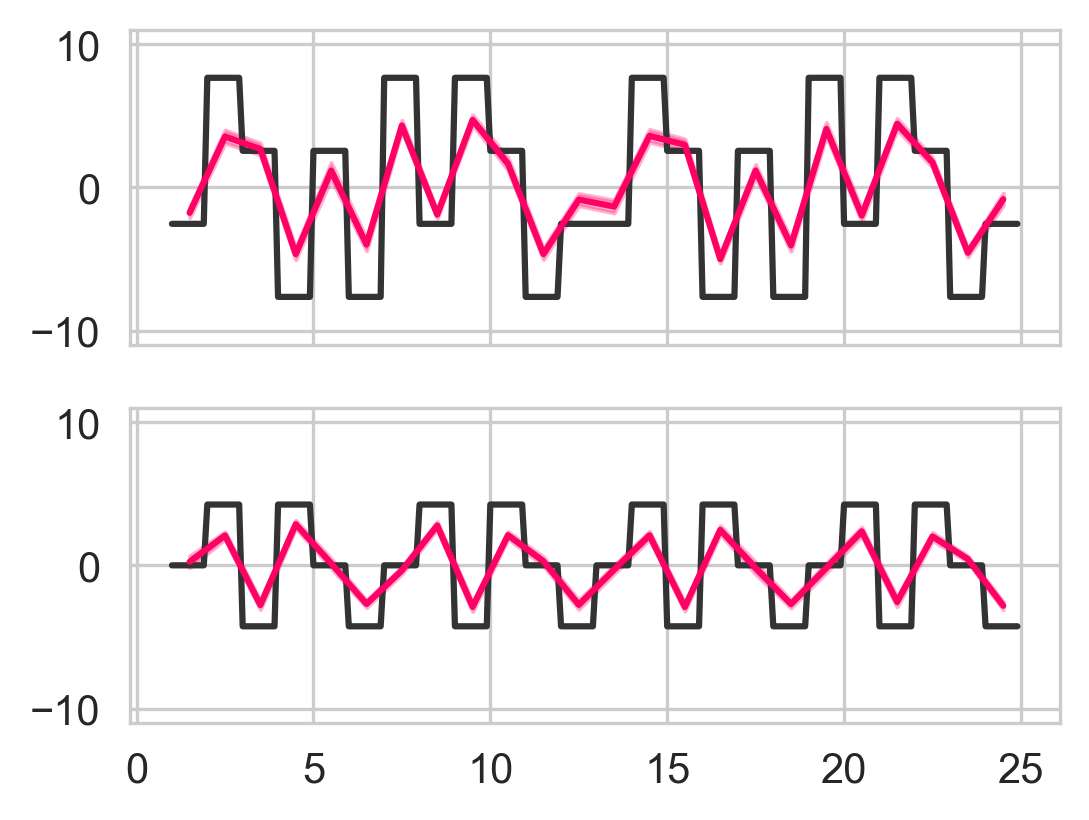

In [15]:

# draw the group-averaged pred_y with standard error band across subjects
time_sta = 1
time_end = time_sta + 24

group_pred_y = np.mean([subject_pred[subject] for subject in subject_pred], axis=0)
group_pred_y_se = sem([subject_pred[subject] for subject in subject_pred], axis=0)

# Plot with error bands
fig, axes = plt.subplots(2, 1, figsize=(4, 3), dpi=300, sharex=True, sharey=True)
axes[0].plot(calibration_time + time_sta, calibration_x, c='#333333')
axes[0].plot(np.arange(time_sta, time_end) + 0.5, group_pred_y[time_sta:time_end, 0], c='#ff0064')
axes[0].fill_between(np.arange(time_sta, time_end) + 0.5,
                     group_pred_y[time_sta:time_end, 0] - group_pred_y_se[time_sta:time_end, 0],
                     group_pred_y[time_sta:time_end, 0] + group_pred_y_se[time_sta:time_end, 0],
                     color='#ff0064', alpha=0.3)
axes[1].plot(calibration_time + time_sta, calibration_y, c='#333333')
axes[1].plot(np.arange(time_sta, time_end) + 0.5, group_pred_y[time_sta:time_end, 1], c='#ff0064')
axes[1].fill_between(np.arange(time_sta, time_end) + 0.5,
                     group_pred_y[time_sta:time_end, 1] - group_pred_y_se[time_sta:time_end, 1],
                     group_pred_y[time_sta:time_end, 1] + group_pred_y_se[time_sta:time_end, 1],
                     color='#ff0064', alpha=0.3)
axes[0].set_ylim(-11, 11)
plt.show()

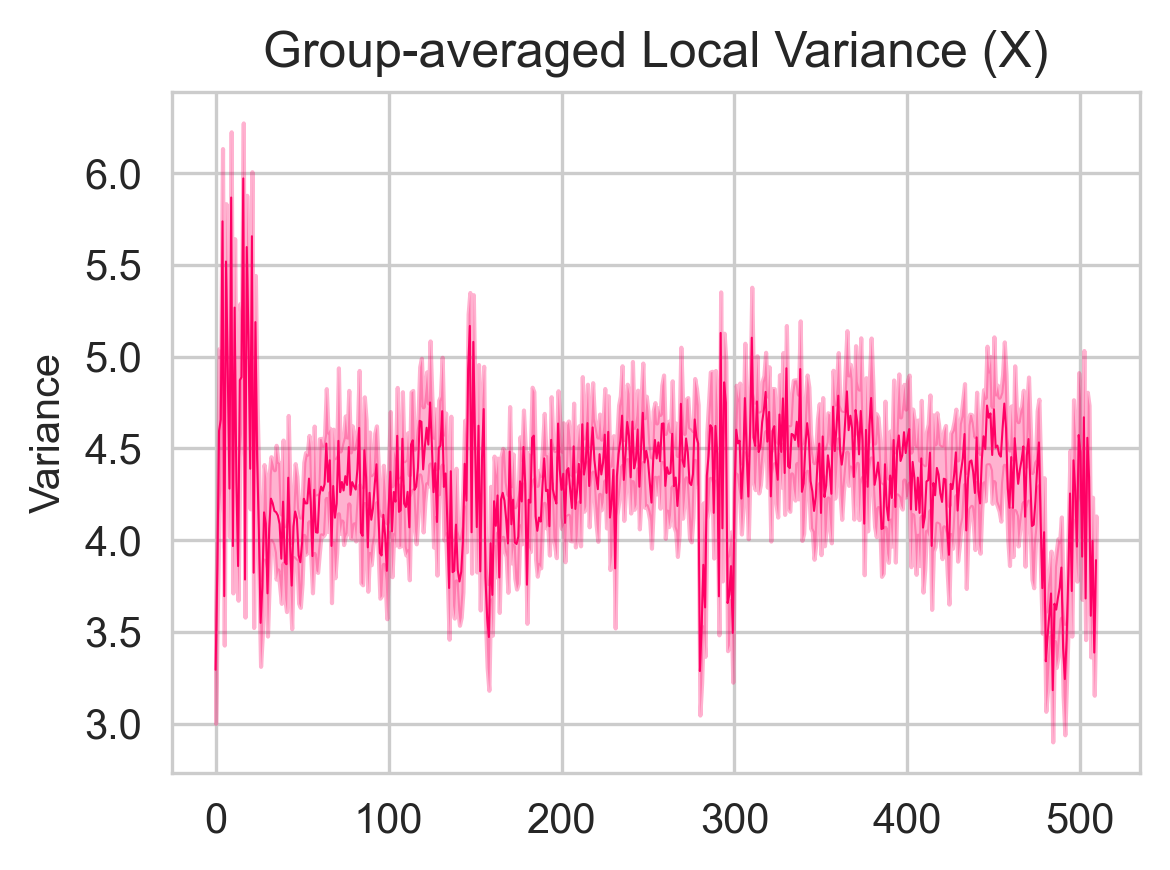

In [17]:
subject_pred = {}
for key in testable_data.keys():
    subject, session, task, run = key
    if subject not in subject_pred:
        subject_pred[subject] = []
    pred_y = np.load(f'results/{subject}_{session}_{run}_pred_finetuned.npy')
    subject_pred[subject].append(pred_y)

window_size = 10
deviation = {subject: [] for subject in subject_pred}
for subject in subject_pred:
    for run_pred in subject_pred[subject]:
        run_deviation = np.zeros(510)
        for t in range(len(run_pred)):
            run_deviation[t] = np.sqrt(run_pred[t, 0]**2 + run_pred[t,1]**2)
        deviation[subject].append(run_deviation)
    deviation[subject] = np.mean(deviation[subject], axis=0)

# Calculate group-averaged local variance and standard error
group_deviation_x = np.mean([deviation[subject] for subject in subject_pred], axis=0)
group_deviation_sem = sem([deviation[subject] for subject in subject_pred], axis=0)

# Plot group-averaged local variance with error bands
time_points = np.arange(510)

fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=300, sharex=True)
ax.plot(time_points, group_deviation_x, c='#ff0064', lw=0.5)
ax.fill_between(time_points, group_deviation_x - group_deviation_sem, 
                     group_deviation_x + group_deviation_sem, color='#ff0064', alpha=0.3)
ax.set_title('Group-averaged Local Variance (X)')
ax.set_ylabel('Variance')

plt.tight_layout()
plt.show()